# 07 - Depth vs Breadth (a parametric experiment)

**Section:** ANNs | **Prereqs:** `ANNs/IrisANN` | **Next:** `ANNs/CodeChallenge.ipynb`

Instead of arguing about architecture, measure it: train 80 models on Iris
(1-8 hidden layers x 1-10 units per layer) and plot accuracy as a heat map.
This *parametric experiment* pattern - wrap training in a function, sweep a
hyperparameter, plot the result - is reused throughout the rest of the course.

**What the map shows:** width buys accuracy quickly and then saturates; extra
depth on a problem this small mostly hurts, because deeper stacks of ReLUs are
harder to optimise at a fixed learning rate and epoch budget.

**Read the numbers with care.** Accuracy is measured on the training data, one
run per cell, so part of the texture in the map is random-seed noise. The fix is
cross-validation (`Cross Validation/`) and repeated runs.

In [51]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F



In [52]:
# Iris via seaborn this time. Species strings are mapped to integer class
# indices; CrossEntropyLoss requires dtype=torch.long.
iris = sns.load_dataset('iris')


data = torch.tensor(iris[iris.columns[0:4]].values).float()

target = torch.tensor(iris["species"].map({
    "setosa" : 0,
    "virginica" : 2,
    "versicolor" : 1
}).values, dtype=torch.long)

In [53]:
# (150,) - one class index per sample, NOT one-hot.
target.shape

torch.Size([150])

In [54]:
# (150, 4) - samples x features.
data.shape

torch.Size([150, 4])

In [60]:
# A model whose SHAPE is an argument: nlayers hidden layers of nNodes units.
# nn.ModuleDict (like nn.ModuleList) registers the layers it holds, so
# model.parameters() finds them. A plain Python dict or list would NOT -
# the layers would exist but never be trained. That is the point of this class.
#
# forward() loops over the same dict in the same order.
# train_model()/backprop() bundle the training loop so the sweep below is a
# two-line nested loop.
class Model(nn.Module):
  def __init__(self, nlayers , nNodes) -> None:
    super().__init__()
    self.nlayers = nlayers
    self.nNodes = nNodes
    # Make a dict of layers, can also sue nn.Modulelist for list of layers
    self.layers = nn.ModuleDict()
    self.layers["Input Layer"] = nn.Linear(4,nNodes)

    for i in range(nlayers):
      self.layers[f"Hidden Layer{i+1}"] = nn.Linear(nNodes, nNodes)


    self.layers["Output Layers"] = nn.Linear(nNodes,3)

  def forward(self,x):

    x = F.relu(self.layers["Input Layer"](x))

    for i in range(self.nlayers):
      x = F.relu(self.layers[f"Hidden Layer{i+1}"](x))

    x = self.layers["Output Layers"](x)

    return x


  def backprop(self,x,y,lr,lossFunc , optimizer, epochs):


   for epoch in range(epochs):

    yhat = self.forward(x)

    loss = lossFunc(yhat,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

   accuracy = 100*torch.mean((torch.argmax(yhat,axis=1) == y).float())
   print(f'Layers {self.nlayers} , Nodes {self.nNodes} : {loss}')
   return accuracy

  def train_model(self, x, y, lr, epochs):

    lossFunc = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(self.parameters(),lr)

    accuracy = self.backprop(x,y,lr,lossFunc,optimizer,epochs)

    return accuracy


In [61]:
# The sweep: 8 depths x 10 widths = 80 models trained from scratch.
# Slow by design; this is what a hyperparameter search actually costs.
nlayers = 8
nNodes = 10
accuracy_list = torch.zeros(nlayers,nNodes)
for i in range(nlayers):
  for j in range(nNodes):
    Classifier = Model(i+1, j+1)
    accuracy_list[i][j] = Classifier.train_model(data,target,0.01, 1000)





Layers 1 , Nodes 1 : 1.0988609790802002
Layers 1 , Nodes 2 : 1.0986183881759644
Layers 1 , Nodes 3 : 0.26175373792648315
Layers 1 , Nodes 4 : 1.098608374595642
Layers 1 , Nodes 5 : 0.2768646776676178
Layers 1 , Nodes 6 : 0.27108240127563477
Layers 1 , Nodes 7 : 0.11158321052789688
Layers 1 , Nodes 8 : 0.14348174631595612
Layers 1 , Nodes 9 : 0.14173001050949097
Layers 1 , Nodes 10 : 0.12440958619117737
Layers 2 , Nodes 1 : 0.4951811730861664
Layers 2 , Nodes 2 : 1.082365870475769
Layers 2 , Nodes 3 : 0.5316784977912903
Layers 2 , Nodes 4 : 0.5043882131576538
Layers 2 , Nodes 5 : 0.44292891025543213
Layers 2 , Nodes 6 : 1.0977650880813599
Layers 2 , Nodes 7 : 1.085242748260498
Layers 2 , Nodes 8 : 0.15425488352775574
Layers 2 , Nodes 9 : 0.38983044028282166
Layers 2 , Nodes 10 : 0.1226765587925911
Layers 3 , Nodes 1 : 1.0986158847808838
Layers 3 , Nodes 2 : 1.0986144542694092
Layers 3 , Nodes 3 : 1.0985627174377441
Layers 3 , Nodes 4 : 1.0107100009918213
Layers 3 , Nodes 5 : 0.802934885

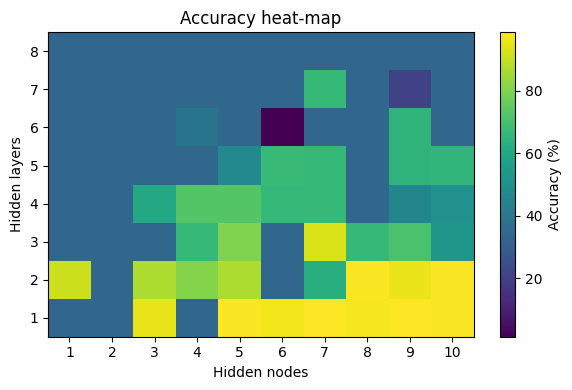

In [62]:
# The heat map. Look for the shape of the good region, not the single best
# cell - one lucky cell is noise, a bright band is a real trend.
plt.figure(figsize=(6,4))
plt.imshow(accuracy_list,
           aspect='auto',
           interpolation='nearest',
           origin='lower',
           cmap='viridis')
plt.colorbar(label="Accuracy (%)")
plt.xticks(range(10), range(1,11))
plt.yticks(range(8),  range(1,9))
plt.xlabel("Hidden nodes")
plt.ylabel("Hidden layers")
plt.title("Accuracy heat-map")
plt.tight_layout()
plt.show()